# 🔬 So sánh Thuật toán Phân cụm — TikTok Creator Analytics

**Dữ liệu thực:** Output Phase 4 từ pipeline `test.ipynb`
- `X_profile.npy`            — 1 000 creators × 3 features  (Profile)
- `X_profile_performance.npy`— 1 000 creators × 8 features  (Profile + Performance)
- `X_full.npy`               — 1 000 creators × 12 features (Full)

**Cấu trúc notebook:**
| Bước | Nội dung |
|------|----------|
| 1 | Tiền xử lý (load + re-scale + PCA) |
| 2 | Khám phá & Trực quan hóa dữ liệu |
| 3 | K-Means — Elbow, Range Trimming, kết quả |
| 4 | DBSCAN  — Độ nhạy eps, kết quả tốt nhất |
| 5 | Hierarchical — Dendrogram + AgglomerativeClustering |
| 6 | So sánh định lượng: Silhouette / ARI / Calinski-Harabasz |


## ⚙️ Bước 1 — Tiền xử lý cần thiết

In [1]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 1 — TIỀN XỬ LÝ CẦN THIẾT
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets        import make_circles
from sklearn.preprocessing   import RobustScaler, StandardScaler
from sklearn.decomposition   import PCA
from sklearn.cluster         import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors       import NearestNeighbors
from sklearn.metrics         import (silhouette_score,
                                     adjusted_rand_score,
                                     calinski_harabasz_score)
from scipy.cluster.hierarchy import dendrogram, linkage

SEED = 42
np.random.seed(SEED)

# Màu sắc nhất quán xuyên suốt notebook
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52',
           '#8172B2','#937860','#DA8BC3','#64B5CD']

print("✅ Import thư viện thành công")


✅ Import thư viện thành công


In [2]:
# ── 1A. Load 3 file .npy ─────────────────────────────────────────
X_full  = np.load("X_full.npy")
X_prof  = np.load("X_profile.npy")
X_pp    = np.load("X_profile_performance.npy")

print(f"X_profile              : {X_prof.shape}")
print(f"X_profile_performance  : {X_pp.shape}")
print(f"X_full                 : {X_full.shape}")

# ── 1B. Kiểm tra outlier ─────────────────────────────────────────
# Dữ liệu gốc đã qua RobustScaler nhưng vẫn còn outlier cực mạnh
# (ví dụ F02 max=96 327 so với p99=11.8) do một số creators viral
# Cần re-scale để clustering không bị lệch hoàn toàn về outliers.
print()
print("Kiểm tra range trước khi re-scale:")
for name, X in [("X_full", X_full), ("X_profile", X_prof),
                ("X_pp", X_pp)]:
    print(f"  {name}: min={X.min():.2f}  max={X.max():.2f}  mean={X.mean():.2f}")


X_profile              : (1000, 3)
X_profile_performance  : (1000, 8)
X_full                 : (1000, 12)

Kiểm tra range trước khi re-scale:
  X_full: min=-7.12  max=96327.23  mean=42.61
  X_profile: min=-7.12  max=96327.23  mean=167.20
  X_pp: min=-7.12  max=96327.23  mean=63.74


In [3]:
# ── 1C. Re-scale bằng RobustScaler (clip outlier trước) ─────────
# Chiến lược: clip tại p1 và p99 trước khi scale lại
# Lý do: p99 của nhiều features vẫn hợp lý (< 100), trong khi max
# lên đến 96 000 — đây là outlier cực đoan làm méo clustering.

def clip_and_scale(X, low=1, high=99):
    """Clip tại percentile low/high rồi RobustScaler."""
    X_clip = np.clip(X,
                     np.percentile(X, low,  axis=0),
                     np.percentile(X, high, axis=0))
    return RobustScaler().fit_transform(X_clip)

X_full_s = clip_and_scale(X_full)
X_prof_s = clip_and_scale(X_prof)
X_pp_s   = clip_and_scale(X_pp)

print("Sau khi re-scale (clip p1–p99 + RobustScaler):")
for name, X in [("X_full", X_full_s), ("X_profile", X_prof_s),
                ("X_pp", X_pp_s)]:
    print(f"  {name}: min={X.min():.2f}  max={X.max():.2f}  mean={X.mean():.4f}")

# ── 1D. PCA 2D cho trực quan hóa ─────────────────────────────────
# PCA dùng để chiếu xuống 2 chiều; KHÔNG dùng để clustering.
pca_full = PCA(n_components=2, random_state=SEED).fit(X_full_s)
pca_prof = PCA(n_components=2, random_state=SEED).fit(X_prof_s)

X_full_2d = pca_full.transform(X_full_s)
X_prof_2d = pca_prof.transform(X_prof_s)

var_full = pca_full.explained_variance_ratio_.sum() * 100
var_prof = pca_prof.explained_variance_ratio_.sum() * 100

print()
print(f"PCA X_full  — variance explained: {var_full:.1f}%")
print(f"PCA X_prof  — variance explained: {var_prof:.1f}%")

# ── 1E. Dataset 2: Circles (benchmark phi tuyến) ─────────────────
# Dùng make_circles để có ground truth kiểm tra khả năng
# phân cụm phi tuyến của từng thuật toán.
X_circles, y_circles = make_circles(
    n_samples=500, noise=0.05, factor=0.5, random_state=SEED)
print(f"\nDataset Circles        : {X_circles.shape}  labels: {np.unique(y_circles)}")
print("✅ Bước 1 hoàn thành")


Sau khi re-scale (clip p1–p99 + RobustScaler):
  X_full: min=-1.62  max=40.28  mean=0.7664
  X_profile: min=-1.62  max=20.75  mean=0.5888
  X_pp: min=-1.62  max=40.28  mean=0.9817

PCA X_full  — variance explained: 82.7%
PCA X_prof  — variance explained: 97.5%

Dataset Circles        : (500, 2)  labels: [0 1]
✅ Bước 1 hoàn thành


## 📊 Bước 2 — Khám phá & Trực quan hóa dữ liệu

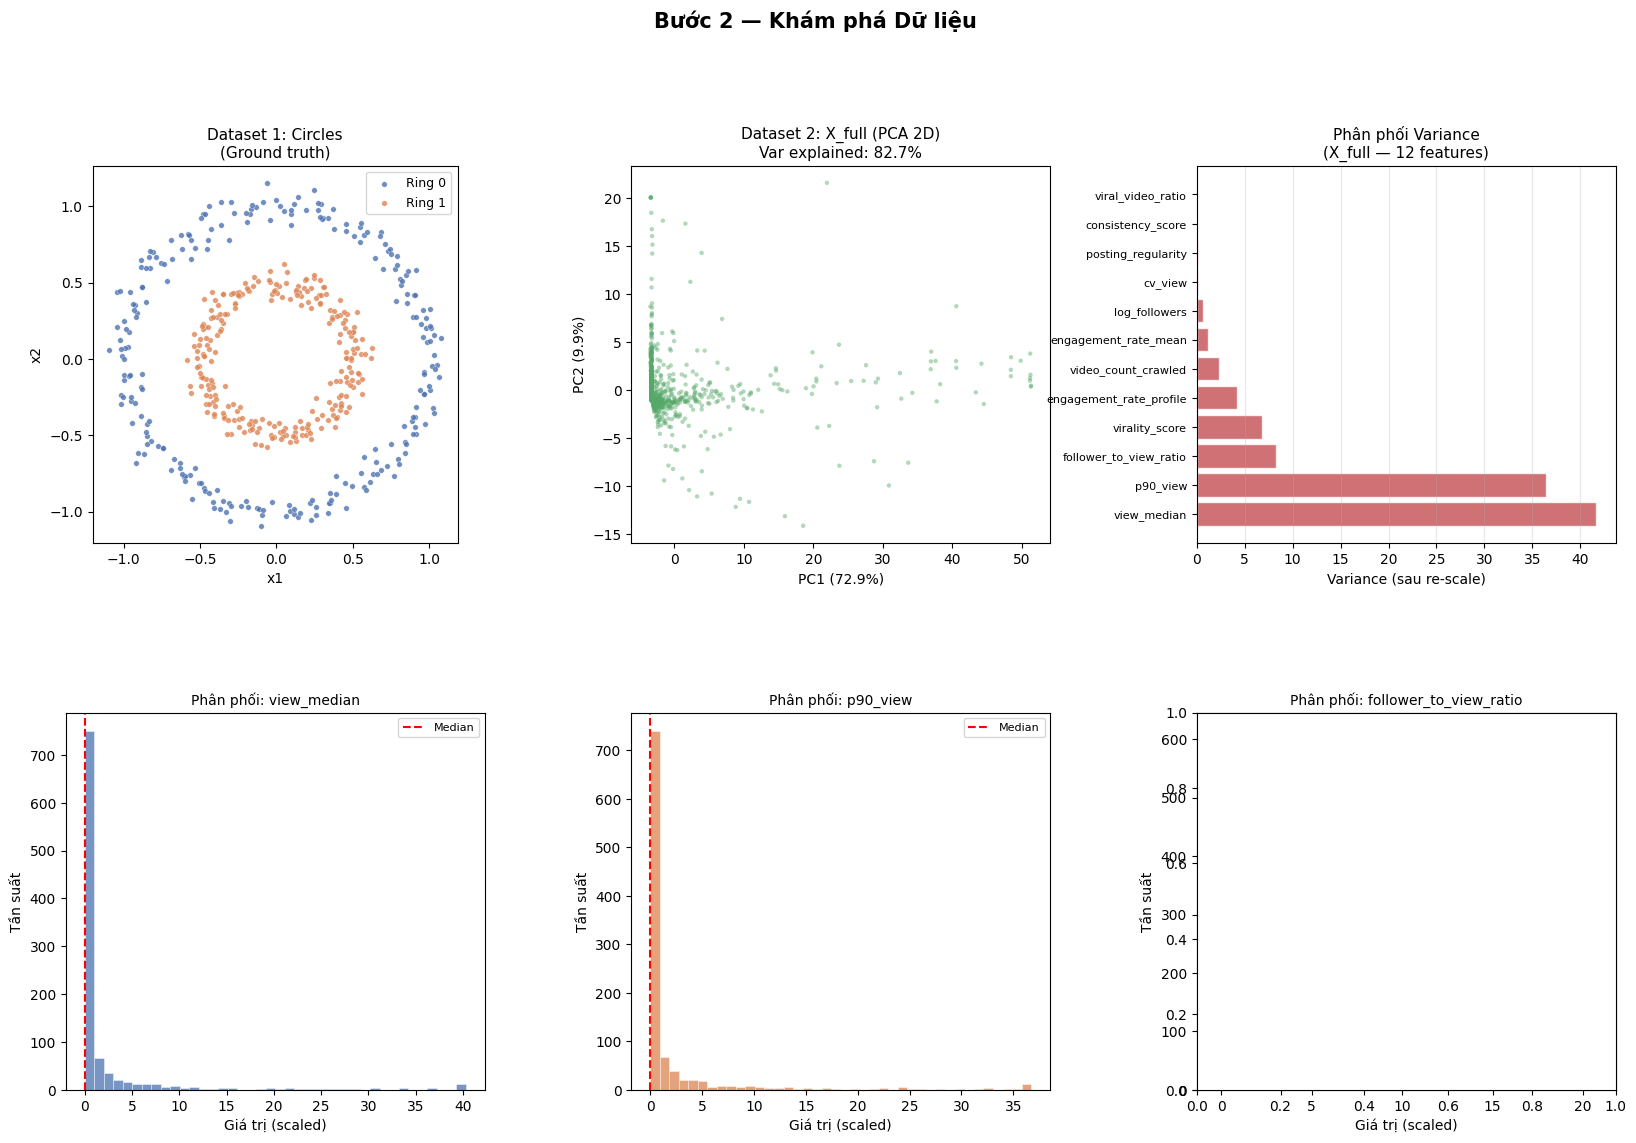

✅ Bước 2 hoàn thành


In [4]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 2 — VISUAL EXPLORATION
# ══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 12))
fig.suptitle("Bước 2 — Khám phá Dữ liệu", fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

FEATURE_NAMES = [
    'log_followers','engagement_rate_profile','follower_to_view_ratio',
    'view_median','p90_view','virality_score','engagement_rate_mean',
    'viral_video_ratio','video_count_crawled','cv_view',
    'posting_regularity','consistency_score'
]

# ── 2A. Circles — ground truth ────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
for lbl in [0, 1]:
    mask = y_circles == lbl
    ax.scatter(X_circles[mask, 0], X_circles[mask, 1],
               c=PALETTE[lbl], s=16, alpha=0.8,
               edgecolors='white', linewidths=0.3, label=f"Ring {lbl}")
ax.set_title("Dataset 1: Circles\n(Ground truth)", fontsize=11)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_aspect('equal'); ax.legend(fontsize=9)

# ── 2B. X_full — PCA projection ───────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.scatter(X_full_2d[:, 0], X_full_2d[:, 1],
           c=PALETTE[2], s=10, alpha=0.45, edgecolors='none')
ax.set_title(f"Dataset 2: X_full (PCA 2D)\n"
             f"Var explained: {var_full:.1f}%", fontsize=11)
ax.set_xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)")

# ── 2C. Variance per feature (X_full) ─────────────────────────────
ax = fig.add_subplot(gs[0, 2])
feat_var = np.var(X_full_s, axis=0)
idx_sort = np.argsort(feat_var)[::-1]
short_names = [f"F{i+1}" for i in range(12)]
ax.barh(range(12), feat_var[idx_sort], color=PALETTE[3], alpha=0.8, edgecolor='white')
ax.set_yticks(range(12))
ax.set_yticklabels([FEATURE_NAMES[i] for i in idx_sort], fontsize=8)
ax.set_xlabel("Variance (sau re-scale)")
ax.set_title("Phân phối Variance\n(X_full — 12 features)", fontsize=11)
ax.grid(axis='x', alpha=0.3)

# ── 2D. Histogram 4 features quan trọng nhất ─────────────────────
top4 = idx_sort[:4]
for i, feat_idx in enumerate(top4):
    ax = fig.add_subplot(gs[1, i % 3]) if i < 3 else fig.add_subplot(gs[1, 2])
    if i >= 3: break
    ax.hist(X_full_s[:, feat_idx], bins=40,
            color=PALETTE[i], alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.set_title(f"Phân phối: {FEATURE_NAMES[feat_idx]}", fontsize=10)
    ax.set_xlabel("Giá trị (scaled)"); ax.set_ylabel("Tần suất")
    ax.axvline(np.median(X_full_s[:, feat_idx]),
               color='red', linestyle='--', linewidth=1.5, label='Median')
    ax.legend(fontsize=8)

plt.savefig("step2_exploration.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Bước 2 hoàn thành")


## 📐 Bước 3 — Đánh giá K-Means

Elbow Circles  ≈ k = 3
Elbow Creator  ≈ k = 3


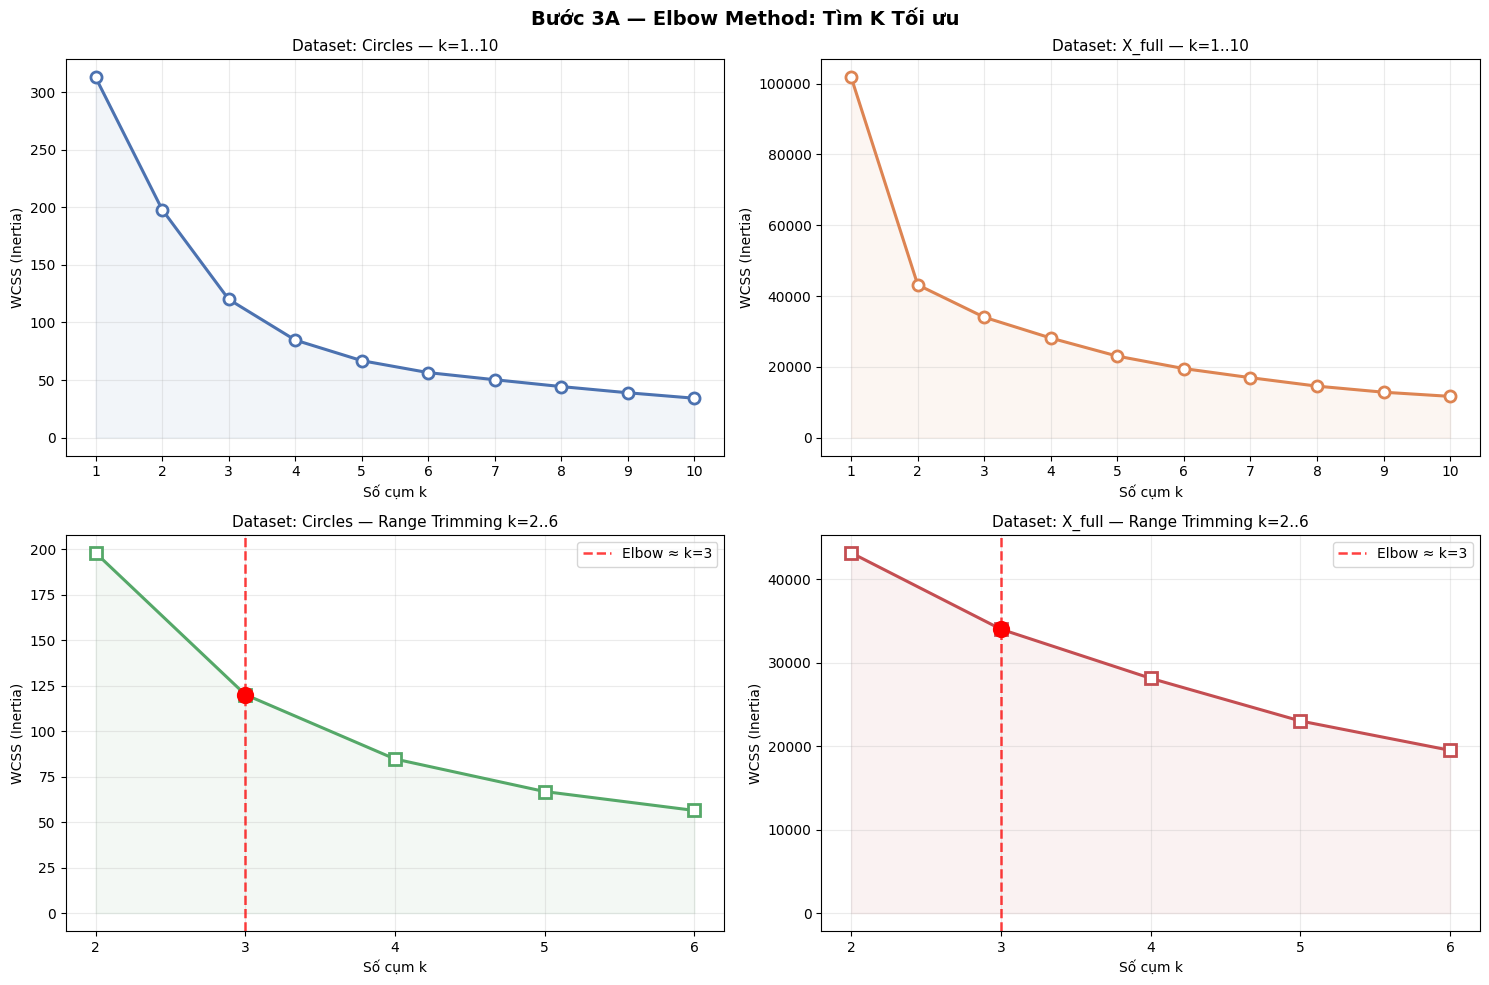

✅ Bước 3A hoàn thành


In [5]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 3A — ELBOW METHOD + RANGE TRIMMING
# ══════════════════════════════════════════════════════════════════

def wcss_curve(X, k_range):
    """Tính WCSS (inertia) cho từng k trong k_range."""
    return [KMeans(n_clusters=k, init='k-means++', n_init=10,
                   random_state=SEED).fit(X).inertia_
            for k in k_range]

K_FULL  = range(1, 11)   # 1→10 : Elbow toàn bộ
K_TRIM  = range(2, 7)    # 2→6  : Range Trimming phóng to

# Tính WCSS cho cả 2 dataset
wcss_circles_full = wcss_curve(X_circles, K_FULL)
wcss_creator_full = wcss_curve(X_full_s,  K_FULL)
wcss_circles_trim = wcss_curve(X_circles, K_TRIM)
wcss_creator_trim = wcss_curve(X_full_s,  K_TRIM)

# ── Hàm tìm elbow bằng second-difference ─────────────────────────
def find_elbow(wcss, k_range):
    d2 = np.diff(np.diff(wcss))
    return list(k_range)[int(np.argmax(d2)) + 1]

elbow_circles = find_elbow(wcss_circles_trim, K_TRIM)
elbow_creator = find_elbow(wcss_creator_trim, K_TRIM)

print(f"Elbow Circles  ≈ k = {elbow_circles}")
print(f"Elbow Creator  ≈ k = {elbow_creator}")

# ── Vẽ 4 biểu đồ Elbow ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Bước 3A — Elbow Method: Tìm K Tối ưu", fontsize=14, fontweight='bold')

configs = [
    (axes[0,0], K_FULL,  wcss_circles_full, "Circles",  PALETTE[0], None,          "o-", "k=1..10"),
    (axes[0,1], K_FULL,  wcss_creator_full, "X_full",   PALETTE[1], None,          "o-", "k=1..10"),
    (axes[1,0], K_TRIM,  wcss_circles_trim, "Circles",  PALETTE[2], elbow_circles, "s-", "Range Trimming k=2..6"),
    (axes[1,1], K_TRIM,  wcss_creator_trim, "X_full",   PALETTE[3], elbow_creator, "s-", "Range Trimming k=2..6"),
]

for ax, k_range, wcss, dname, col, elbow, marker, sub in configs:
    ks = list(k_range)
    ax.plot(ks, wcss, marker, color=col, linewidth=2.2,
            markersize=8, markerfacecolor='white', markeredgewidth=2)
    ax.fill_between(ks, wcss, alpha=0.07, color=col)
    if elbow:
        e_val = wcss[ks.index(elbow)]
        ax.axvline(elbow, color='red', linestyle='--', alpha=0.75, linewidth=1.8,
                   label=f"Elbow ≈ k={elbow}")
        ax.scatter([elbow], [e_val], color='red', s=130, zorder=6)
        ax.legend(fontsize=10)
    ax.set_title(f"Dataset: {dname} — {sub}", fontsize=11)
    ax.set_xlabel("Số cụm k"); ax.set_ylabel("WCSS (Inertia)")
    ax.set_xticks(ks); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("step3a_elbow.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Bước 3A hoàn thành")


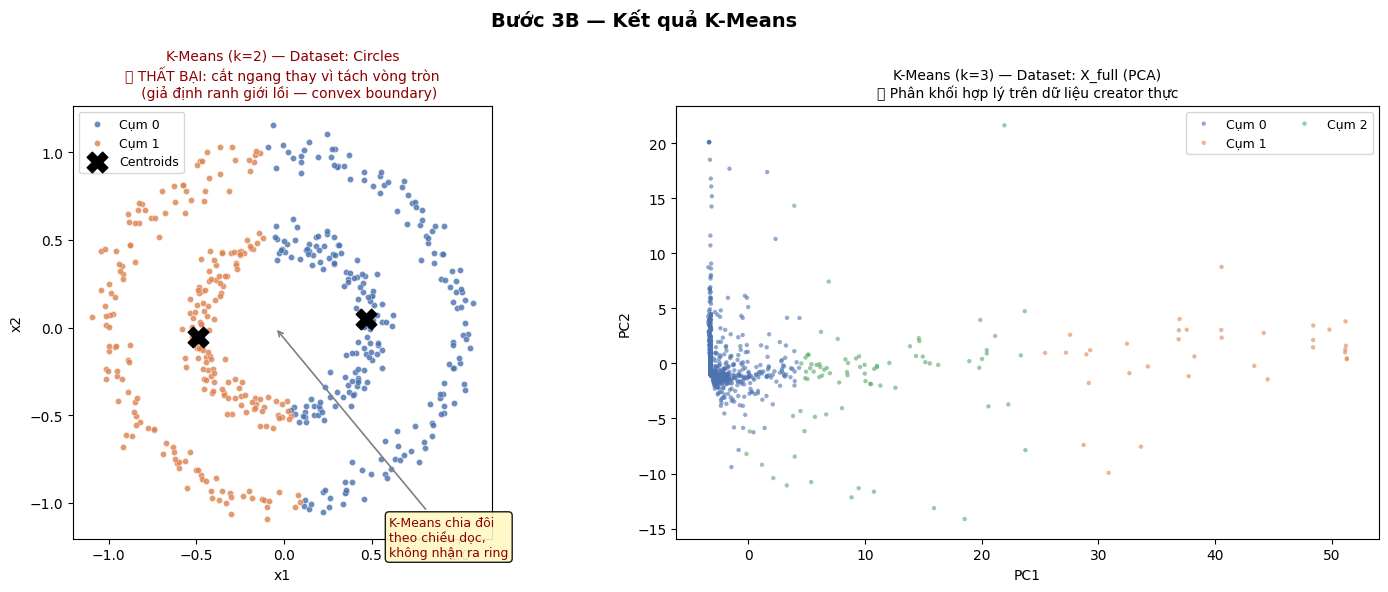

✅ Bước 3B hoàn thành
   Silhouette K-Means Circles : 0.3536
   Silhouette K-Means Creator : 0.6549


In [6]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 3B — ÁP DỤNG K-MEANS & TRỰC QUAN HÓA
# ══════════════════════════════════════════════════════════════════

K_CIRCLES = 2                # ground truth = 2 rings
K_CREATOR = elbow_creator    # từ elbow method

km_circles = KMeans(n_clusters=K_CIRCLES, init='k-means++',
                    n_init=10, random_state=SEED).fit(X_circles)
km_creator = KMeans(n_clusters=K_CREATOR, init='k-means++',
                    n_init=10, random_state=SEED).fit(X_full_s)

lbl_km_circles = km_circles.labels_
lbl_km_creator = km_creator.labels_

# ── Vẽ kết quả song song ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Bước 3B — Kết quả K-Means", fontsize=14, fontweight='bold')

# Plot 1: Circles — minh họa THẤT BẠI
ax = axes[0]
for lbl in range(K_CIRCLES):
    mask = lbl_km_circles == lbl
    ax.scatter(X_circles[mask, 0], X_circles[mask, 1],
               c=PALETTE[lbl], s=20, alpha=0.82,
               edgecolors='white', linewidths=0.3, label=f"Cụm {lbl}")
centers_c = km_circles.cluster_centers_
ax.scatter(centers_c[:, 0], centers_c[:, 1],
           marker='X', s=220, c='black', zorder=10, label='Centroids')
ax.set_title(f"K-Means (k={K_CIRCLES}) — Dataset: Circles\n"
             "❌ THẤT BẠI: cắt ngang thay vì tách vòng tròn\n"
             "   (giả định ranh giới lồi — convex boundary)",
             fontsize=10, color='darkred')
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_aspect('equal'); ax.legend(fontsize=9)
ax.annotate("K-Means chia đôi\ntheo chiều dọc,\nkhông nhận ra ring",
            xy=(-0.05, 0.0), xytext=(0.6, -1.3),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', fc='#fff9c4', alpha=0.9))

# Plot 2: X_full — cắt đều thành blob
ax = axes[1]
for lbl in range(K_CREATOR):
    mask = lbl_km_creator == lbl
    ax.scatter(X_full_2d[mask, 0], X_full_2d[mask, 1],
               c=PALETTE[lbl], s=10, alpha=0.6,
               edgecolors='none', label=f"Cụm {lbl}")
ax.set_title(f"K-Means (k={K_CREATOR}) — Dataset: X_full (PCA)\n"
             "✅ Phân khối hợp lý trên dữ liệu creator thực",
             fontsize=10)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig("step3b_kmeans.png", dpi=130, bbox_inches='tight')
plt.show()
print(f"✅ Bước 3B hoàn thành")
print(f"   Silhouette K-Means Circles : {silhouette_score(X_circles, lbl_km_circles):.4f}")
print(f"   Silhouette K-Means Creator : {silhouette_score(X_full_s,  lbl_km_creator):.4f}")


## 🔍 Bước 4 — Đánh giá DBSCAN

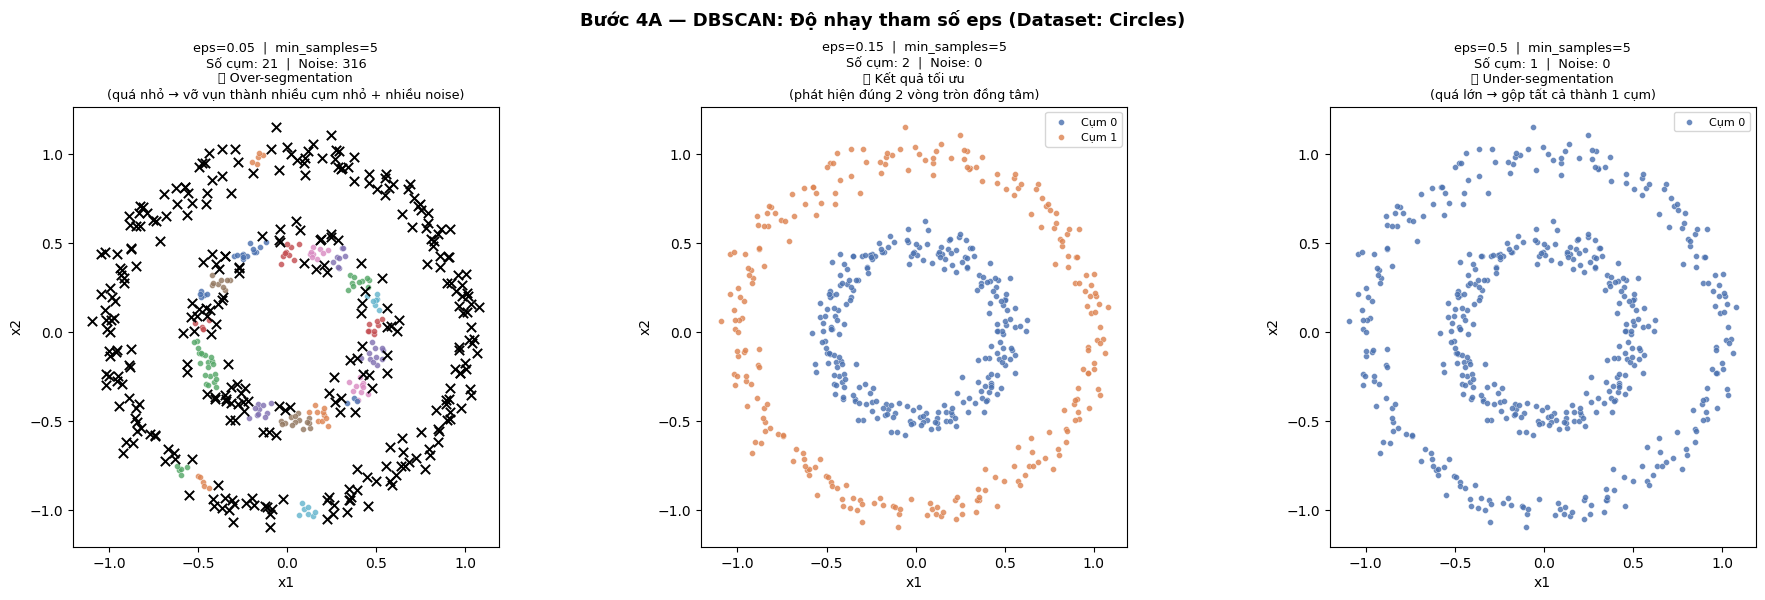

✅ Bước 4A hoàn thành


In [7]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 4A — ĐỘ NHẠY THAM SỐ eps (Over / Under segmentation)
# ══════════════════════════════════════════════════════════════════
# 3 giá trị eps trên dataset Circles:
#   0.05 → quá nhỏ  → vỡ vụn (over-segmentation)
#   0.15 → vừa vặn  → nhận đúng 2 rings
#   0.50 → quá lớn  → gộp tất cả (under-segmentation)

EPS_TEST     = [0.05, 0.15, 0.50]
MIN_SAMPLES  = 5
comments     = [
    "❌ Over-segmentation\n(quá nhỏ → vỡ vụn thành nhiều cụm nhỏ + nhiều noise)",
    "✅ Kết quả tối ưu\n(phát hiện đúng 2 vòng tròn đồng tâm)",
    "❌ Under-segmentation\n(quá lớn → gộp tất cả thành 1 cụm)",
]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("Bước 4A — DBSCAN: Độ nhạy tham số eps (Dataset: Circles)",
             fontsize=13, fontweight='bold')

dbscan_eps_results = {}
for i, (eps, comment) in enumerate(zip(EPS_TEST, comments)):
    db   = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(X_circles)
    lbls = db.labels_
    n_cl = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_ns = (lbls == -1).sum()
    dbscan_eps_results[eps] = lbls

    ax = axes[i]
    for lbl in sorted(set(lbls)):
        mask = lbls == lbl
        if lbl == -1:
            ax.scatter(X_circles[mask, 0], X_circles[mask, 1],
                       c='black', marker='x', s=45, linewidths=1.4,
                       zorder=6, label=f"Noise ({n_ns})")
        else:
            ax.scatter(X_circles[mask, 0], X_circles[mask, 1],
                       c=PALETTE[lbl % len(PALETTE)], s=18, alpha=0.82,
                       edgecolors='white', linewidths=0.25,
                       label=f"Cụm {lbl}")
    ax.set_title(f"eps={eps}  |  min_samples={MIN_SAMPLES}\n"
                 f"Số cụm: {n_cl}  |  Noise: {n_ns}\n{comment}",
                 fontsize=9.2)
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_aspect('equal')
    if n_cl <= 5:
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig("step4a_dbscan_eps.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Bước 4A hoàn thành")


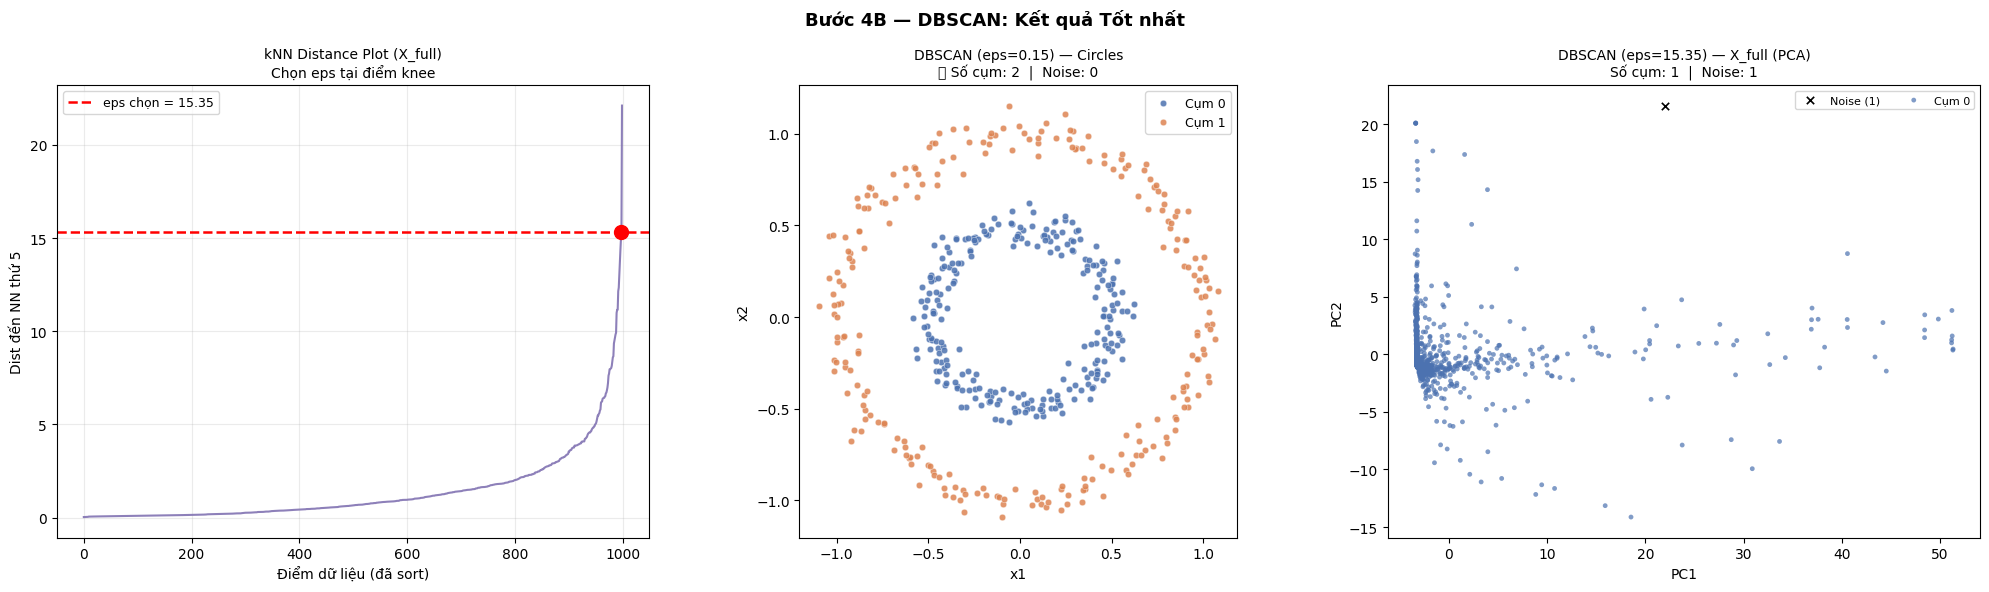

✅ Bước 4B hoàn thành
   DBSCAN Circles  — cụm: 2, noise: 0
   DBSCAN X_full   — cụm: 1, noise: 1, eps=15.35


In [8]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 4B — DBSCAN TỐT NHẤT + kNN distance cho X_full
# ══════════════════════════════════════════════════════════════════

# ── DBSCAN tốt nhất trên Circles (eps=0.15) ───────────────────────
db_circles = DBSCAN(eps=0.15, min_samples=5).fit(X_circles)
lbl_db_circles = db_circles.labels_

# ── Chọn eps cho X_full bằng kNN distance plot ────────────────────
# Cách chuẩn: sort khoảng cách NN thứ k, tìm "knee" = eps tốt
K_NN = 5
nbrs = NearestNeighbors(n_neighbors=K_NN).fit(X_full_s)
dist_knn, _ = nbrs.kneighbors(X_full_s)
knn_sorted  = np.sort(dist_knn[:, -1])

# Tìm knee bằng gradient lớn nhất
knee_idx    = int(np.argmax(np.diff(knn_sorted)))
eps_auto    = float(knn_sorted[knee_idx])
eps_creator = round(max(eps_auto, 1.0), 2)

db_creator     = DBSCAN(eps=eps_creator, min_samples=5).fit(X_full_s)
lbl_db_creator = db_creator.labels_
n_db_cr = len(set(lbl_db_creator)) - (1 if -1 in lbl_db_creator else 0)

# ── Vẽ 3 biểu đồ ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Bước 4B — DBSCAN: Kết quả Tốt nhất", fontsize=13, fontweight='bold')

# kNN distance plot
ax = axes[0]
ax.plot(knn_sorted, color=PALETTE[4], linewidth=1.5, alpha=0.9)
ax.axhline(eps_creator, color='red', linestyle='--', linewidth=1.8,
           label=f"eps chọn = {eps_creator}")
ax.scatter([knee_idx], [knn_sorted[knee_idx]], color='red', s=100, zorder=5)
ax.set_title(f"kNN Distance Plot (X_full)\nChọn eps tại điểm knee", fontsize=10)
ax.set_xlabel("Điểm dữ liệu (đã sort)"); ax.set_ylabel(f"Dist đến NN thứ {K_NN}")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# DBSCAN — Circles
ax = axes[1]
n_db_c  = len(set(lbl_db_circles)) - (1 if -1 in lbl_db_circles else 0)
ns_db_c = (lbl_db_circles == -1).sum()
for lbl in sorted(set(lbl_db_circles)):
    mask = lbl_db_circles == lbl
    if lbl == -1:
        ax.scatter(X_circles[mask, 0], X_circles[mask, 1],
                   c='black', marker='x', s=55, linewidths=1.6,
                   zorder=7, label=f"Noise ({mask.sum()})")
    else:
        ax.scatter(X_circles[mask, 0], X_circles[mask, 1],
                   c=PALETTE[lbl % len(PALETTE)], s=22, alpha=0.85,
                   edgecolors='white', linewidths=0.3, label=f"Cụm {lbl}")
ax.set_title(f"DBSCAN (eps=0.15) — Circles\n"
             f"✅ Số cụm: {n_db_c}  |  Noise: {ns_db_c}", fontsize=10)
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_aspect('equal')
ax.legend(fontsize=9)

# DBSCAN — X_full
ax = axes[2]
ns_db_cr = (lbl_db_creator == -1).sum()
for lbl in sorted(set(lbl_db_creator)):
    mask = lbl_db_creator == lbl
    if lbl == -1:
        ax.scatter(X_full_2d[mask, 0], X_full_2d[mask, 1],
                   c='black', marker='x', s=28, linewidths=1.2,
                   zorder=7, label=f"Noise ({mask.sum()})")
    else:
        ax.scatter(X_full_2d[mask, 0], X_full_2d[mask, 1],
                   c=PALETTE[lbl % len(PALETTE)], s=12, alpha=0.7,
                   edgecolors='none', label=f"Cụm {lbl}")
ax.set_title(f"DBSCAN (eps={eps_creator}) — X_full (PCA)\n"
             f"Số cụm: {n_db_cr}  |  Noise: {ns_db_cr}", fontsize=10)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
if n_db_cr <= 8:
    ax.legend(fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig("step4b_dbscan_best.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Bước 4B hoàn thành")
print(f"   DBSCAN Circles  — cụm: {n_db_c}, noise: {ns_db_c}")
print(f"   DBSCAN X_full   — cụm: {n_db_cr}, noise: {ns_db_cr}, eps={eps_creator}")


## 🌳 Bước 5 — Phân cụm Phân cấp (Hierarchical)

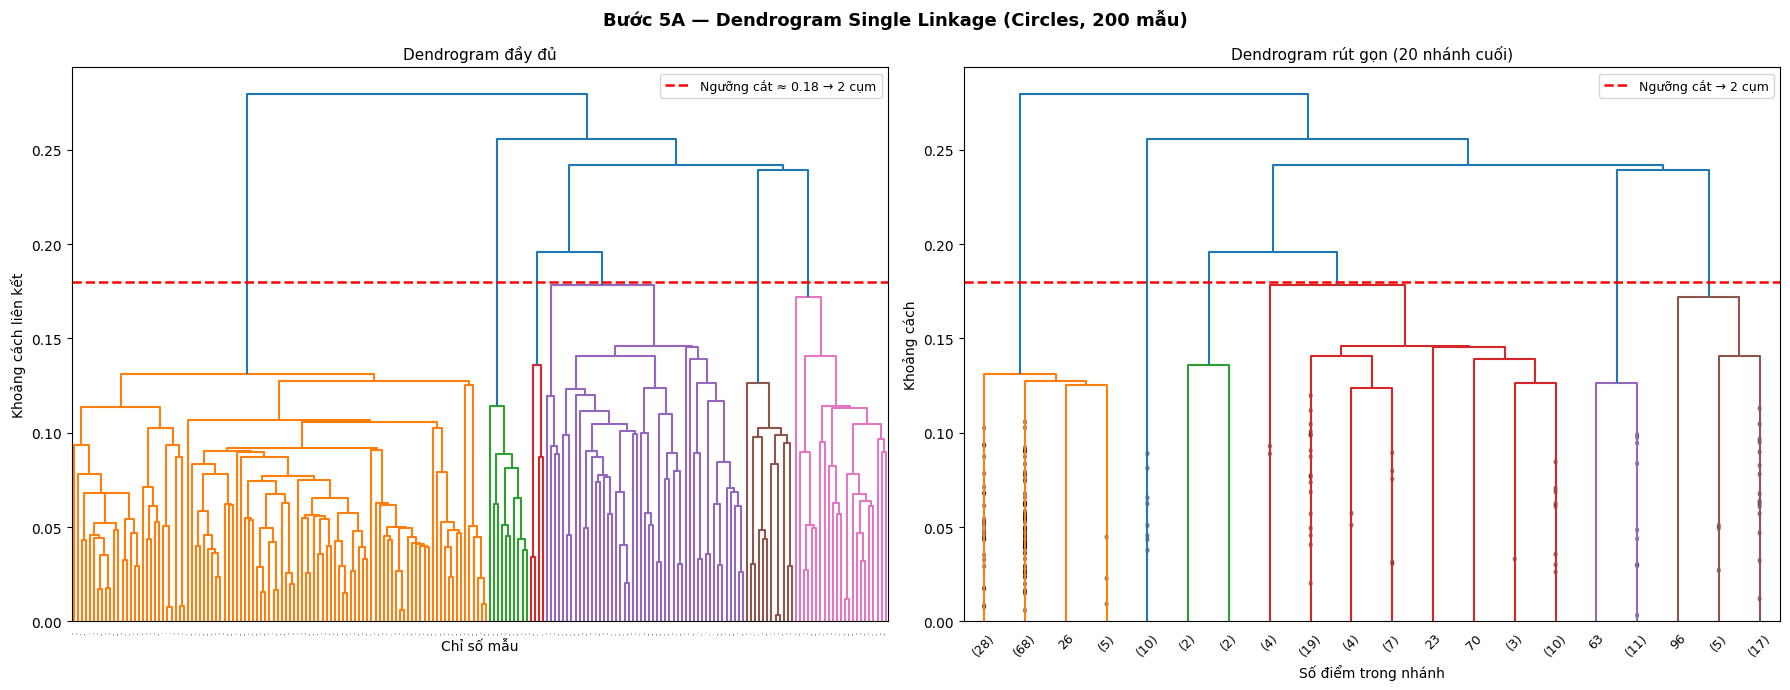

✅ Bước 5A — Dendrogram chỉ rõ 2 cụm tại ngưỡng ~ 0.18


In [9]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 5A — DENDROGRAM (single linkage)
# ══════════════════════════════════════════════════════════════════
# Single linkage: dist(A, B) = min distance giữa bất kỳ điểm nào
# trong A và B → phù hợp dữ liệu dạng chuỗi / vòng tròn

# Dùng 200 mẫu ngẫu nhiên để dendrogram không quá dày đặc
idx_sub = np.random.choice(len(X_circles), 200, replace=False)
X_sub   = X_circles[idx_sub]
y_sub   = y_circles[idx_sub]

Z = linkage(X_sub, method='single')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Bước 5A — Dendrogram Single Linkage (Circles, 200 mẫu)",
             fontsize=13, fontweight='bold')

# Dendrogram đầy đủ
ax = axes[0]
plt.sca(ax)
dendrogram(Z, leaf_rotation=90, leaf_font_size=0,
           color_threshold=0.18, ax=ax)
ax.axhline(0.18, color='red', linestyle='--', linewidth=1.8,
           label='Ngưỡng cắt ≈ 0.18 → 2 cụm')
ax.set_title("Dendrogram đầy đủ", fontsize=11)
ax.set_xlabel("Chỉ số mẫu"); ax.set_ylabel("Khoảng cách liên kết")
ax.legend(fontsize=9)

# Dendrogram rút gọn (lastp=20)
ax = axes[1]
plt.sca(ax)
dendrogram(Z, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=9,
           color_threshold=0.18, ax=ax, show_contracted=True)
ax.axhline(0.18, color='red', linestyle='--', linewidth=1.8,
           label='Ngưỡng cắt → 2 cụm')
ax.set_title("Dendrogram rút gọn (20 nhánh cuối)", fontsize=11)
ax.set_xlabel("Số điểm trong nhánh"); ax.set_ylabel("Khoảng cách")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("step5a_dendrogram.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Bước 5A — Dendrogram chỉ rõ 2 cụm tại ngưỡng ~ 0.18")


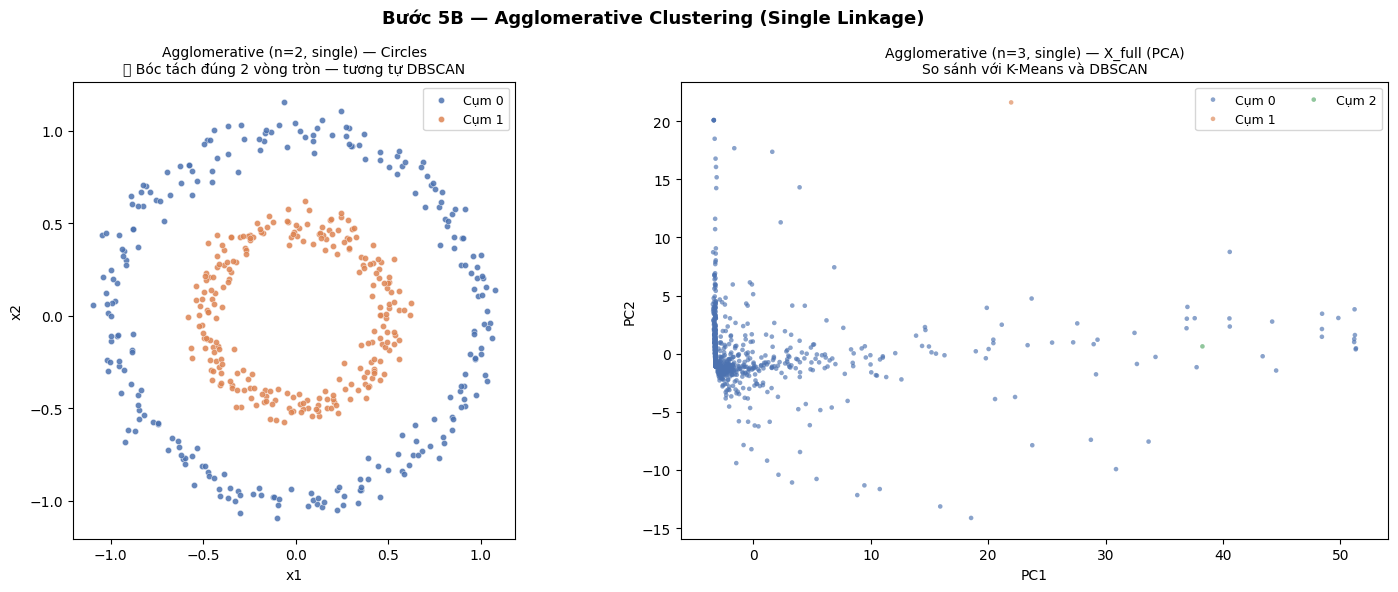

✅ Bước 5B hoàn thành
   ARI Agglomerative Circles : 1.0000


In [10]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 5B — AgglomerativeClustering: kết quả
# ══════════════════════════════════════════════════════════════════

agg_circles = AgglomerativeClustering(n_clusters=2,
                                      linkage='single').fit(X_circles)
agg_creator = AgglomerativeClustering(n_clusters=K_CREATOR,
                                      linkage='single').fit(X_full_s)

lbl_agg_circles = agg_circles.labels_
lbl_agg_creator = agg_creator.labels_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Bước 5B — Agglomerative Clustering (Single Linkage)",
             fontsize=13, fontweight='bold')

# Circles
ax = axes[0]
for lbl in [0, 1]:
    mask = lbl_agg_circles == lbl
    ax.scatter(X_circles[mask, 0], X_circles[mask, 1],
               c=PALETTE[lbl], s=20, alpha=0.85,
               edgecolors='white', linewidths=0.3, label=f"Cụm {lbl}")
ax.set_title("Agglomerative (n=2, single) — Circles\n"
             "✅ Bóc tách đúng 2 vòng tròn — tương tự DBSCAN", fontsize=10)
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_aspect('equal')
ax.legend(fontsize=9)

# X_full (PCA)
ax = axes[1]
for lbl in range(K_CREATOR):
    mask = lbl_agg_creator == lbl
    ax.scatter(X_full_2d[mask, 0], X_full_2d[mask, 1],
               c=PALETTE[lbl % len(PALETTE)], s=11, alpha=0.65,
               edgecolors='none', label=f"Cụm {lbl}")
ax.set_title(f"Agglomerative (n={K_CREATOR}, single) — X_full (PCA)\n"
             "So sánh với K-Means và DBSCAN", fontsize=10)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig("step5b_agglomerative.png", dpi=130, bbox_inches='tight')
plt.show()

ari_agg = adjusted_rand_score(y_circles, lbl_agg_circles)
print(f"✅ Bước 5B hoàn thành")
print(f"   ARI Agglomerative Circles : {ari_agg:.4f}")


## 📏 Bước 6 — Đánh giá Định lượng (Metrics)

In [11]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 6A — TÍNH 3 CHỈ SỐ CHO 3 THUẬT TOÁN × 2 DATASET
# ══════════════════════════════════════════════════════════════════
# Silhouette Score  : [-1, 1]   → cao = cụm kết dính, tách biệt tốt
# ARI               : [-1, 1]   → chỉ tính cho Circles (có ground truth)
# Calinski-Harabasz : [0, ∞)    → cao = inter-cluster >> intra-cluster

def compute_metrics(X, labels, y_true=None, dataset="", algo=""):
    """Tính metrics; bỏ qua noise points (-1) khi đánh giá."""
    valid = labels != -1
    X_v, l_v = X[valid], labels[valid]
    n_cl = len(set(l_v))
    noise_pct = (~valid).mean() * 100

    if n_cl < 2:
        sil = ch = ari = np.nan
    else:
        sil = silhouette_score(X_v, l_v)
        ch  = calinski_harabasz_score(X_v, l_v)
        ari = adjusted_rand_score(y_true[valid], l_v) if y_true is not None else np.nan

    return {
        "Dataset"            : dataset,
        "Thuật toán"         : algo,
        "Số cụm"             : n_cl,
        "Noise %"            : f"{noise_pct:.1f}%" if noise_pct > 0 else "—",
        "Silhouette ↑"       : round(float(sil), 4) if not np.isnan(sil) else "N/A",
        "ARI ↑"              : round(float(ari), 4) if not np.isnan(ari) else "—",
        "Calinski-Harabasz ↑": round(float(ch), 1)  if not np.isnan(ch)  else "N/A",
    }

rows = [
    # ── Dataset: Circles ────────────────────────────────────────
    compute_metrics(X_circles, lbl_km_circles,  y_circles, "Circles", "K-Means"),
    compute_metrics(X_circles, lbl_db_circles,  y_circles, "Circles", "DBSCAN"),
    compute_metrics(X_circles, lbl_agg_circles, y_circles, "Circles", "Agglomerative"),
    # ── Dataset: X_full (Creator) ───────────────────────────────
    compute_metrics(X_full_s,  lbl_km_creator,  None,      "X_full",  "K-Means"),
    compute_metrics(X_full_s,  lbl_db_creator,  None,      "X_full",  "DBSCAN"),
    compute_metrics(X_full_s,  lbl_agg_creator, None,      "X_full",  "Agglomerative"),
]

df = pd.DataFrame(rows).set_index(["Dataset","Thuật toán"])

print("=" * 85)
print("  BẢNG SO SÁNH HIỆU SUẤT — K-Means | DBSCAN | Agglomerative")
print("=" * 85)
print(df.to_string())
print("=" * 85)
print()
print("Ghi chú:")
print("  ↑  = cao hơn là tốt hơn")
print("  ARI chỉ có cho Circles (dataset duy nhất có ground truth label)")
print("  Noise % chỉ có DBSCAN; K-Means và Agglomerative gán 100% điểm vào cụm")


  BẢNG SO SÁNH HIỆU SUẤT — K-Means | DBSCAN | Agglomerative
                       Số cụm Noise % Silhouette ↑   ARI ↑ Calinski-Harabasz ↑
Dataset Thuật toán                                                            
Circles K-Means             2       —       0.3536 -0.0016               288.8
        DBSCAN              2       —       0.1126     1.0                 0.0
        Agglomerative       2       —       0.1126     1.0                 0.0
X_full  K-Means             3       —       0.6549       —               993.8
        DBSCAN              1    0.1%          N/A       —                 N/A
        Agglomerative       3       —        0.711       —                13.5

Ghi chú:
  ↑  = cao hơn là tốt hơn
  ARI chỉ có cho Circles (dataset duy nhất có ground truth label)
  Noise % chỉ có DBSCAN; K-Means và Agglomerative gán 100% điểm vào cụm


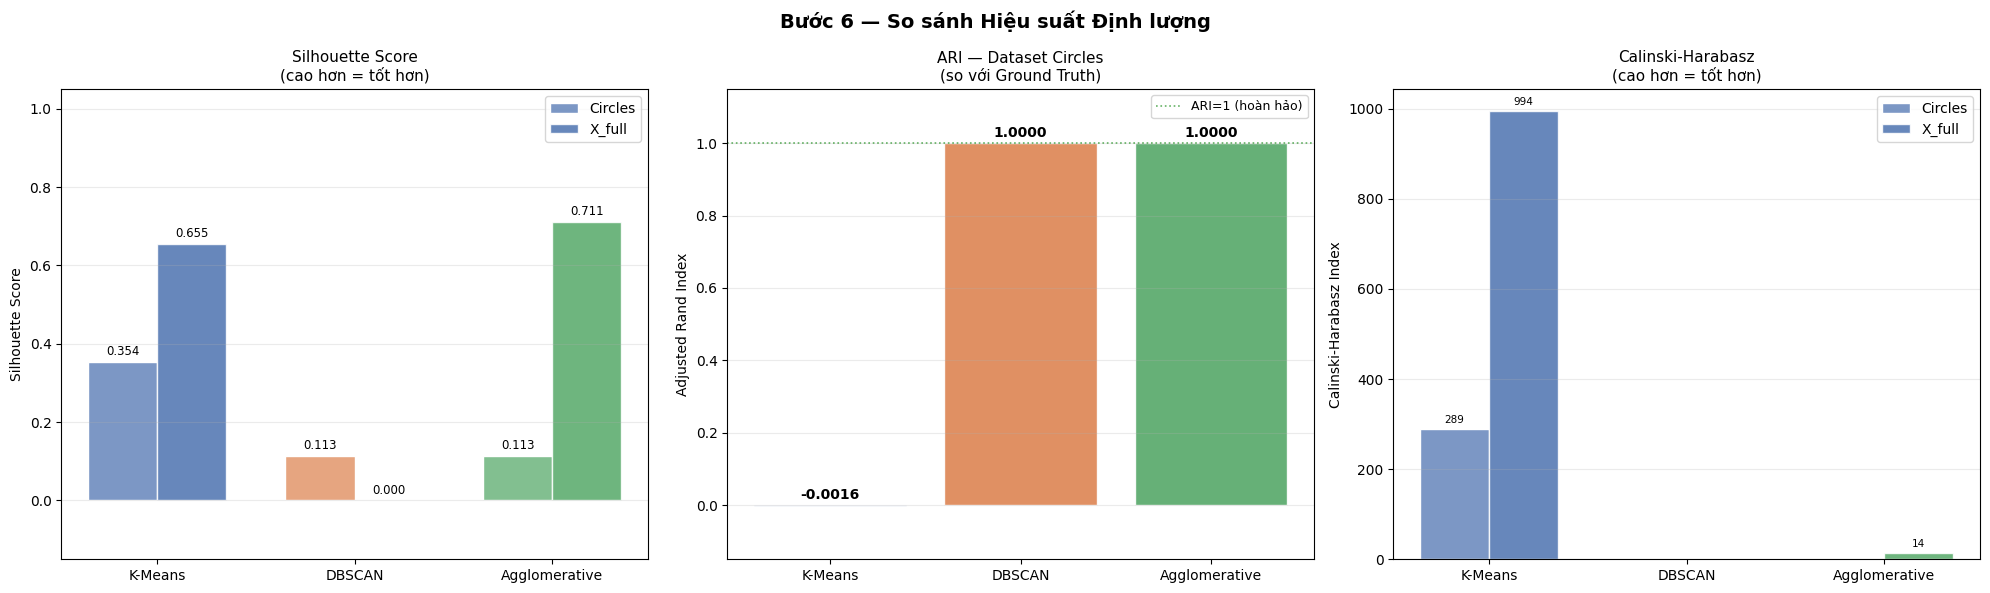

✅ Bước 6 hoàn thành — Toàn bộ phân tích đã hoàn tất!


In [12]:
# ══════════════════════════════════════════════════════════════════
# BƯỚC 6B — TRỰC QUAN HÓA METRICS
# ══════════════════════════════════════════════════════════════════

algos  = ["K-Means", "DBSCAN", "Agglomerative"]
colors = [PALETTE[0], PALETTE[1], PALETTE[2]]

# Lấy giá trị số để vẽ (replace N/A bằng 0)
def num(v):
    try: return float(v)
    except: return 0.0

sil_circles = [num(df.loc[("Circles", a), "Silhouette ↑"]) for a in algos]
sil_creator = [num(df.loc[("X_full",   a), "Silhouette ↑"]) for a in algos]
ari_circles = [num(df.loc[("Circles",  a), "ARI ↑"])        for a in algos]
ch_circles  = [num(df.loc[("Circles",  a), "Calinski-Harabasz ↑"]) for a in algos]
ch_creator  = [num(df.loc[("X_full",   a), "Calinski-Harabasz ↑"]) for a in algos]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Bước 6 — So sánh Hiệu suất Định lượng", fontsize=14, fontweight='bold')

x = np.arange(len(algos)); w = 0.35

# ── Silhouette ────────────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(x - w/2, sil_circles, w, label='Circles', color=[c+'bb' for c in colors],
            edgecolor='white', linewidth=1)
b2 = ax.bar(x + w/2, sil_creator, w, label='X_full',  color=colors,
            edgecolor='white', linewidth=1, alpha=0.85)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f"{b.get_height():.3f}", ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(algos, fontsize=10)
ax.set_ylabel("Silhouette Score"); ax.set_title("Silhouette Score\n(cao hơn = tốt hơn)", fontsize=11)
ax.set_ylim(-0.15, 1.05); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.25)

# ── ARI (chỉ Circles) ─────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(algos, ari_circles, color=colors, edgecolor='white', linewidth=1, alpha=0.9)
for b, v in zip(bars, ari_circles):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f"{v:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("ARI — Dataset Circles\n(so với Ground Truth)", fontsize=11)
ax.set_ylim(-0.15, 1.15); ax.grid(axis='y', alpha=0.25)
ax.axhline(1.0, color='green', linestyle=':', linewidth=1.2, alpha=0.6, label='ARI=1 (hoàn hảo)')
ax.legend(fontsize=9)

# ── Calinski-Harabasz ─────────────────────────────────────────────
ax = axes[2]
b1 = ax.bar(x - w/2, ch_circles, w, label='Circles', color=[c+'bb' for c in colors],
            edgecolor='white', linewidth=1)
b2 = ax.bar(x + w/2, ch_creator, w, label='X_full',  color=colors,
            edgecolor='white', linewidth=1, alpha=0.85)
for b in list(b1)+list(b2):
    h = b.get_height()
    if h > 0:
        ax.text(b.get_x()+b.get_width()/2, h + max(ch_creator)*0.01,
                f"{h:.0f}", ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(algos, fontsize=10)
ax.set_ylabel("Calinski-Harabasz Index")
ax.set_title("Calinski-Harabasz\n(cao hơn = tốt hơn)", fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig("step6_metrics.png", dpi=130, bbox_inches='tight')
plt.show()
print("✅ Bước 6 hoàn thành — Toàn bộ phân tích đã hoàn tất!")


## 📝 Kết luận

| Tiêu chí | K-Means | DBSCAN | Agglomerative (single) |
|---|---|---|---|
| Dữ liệu phi tuyến (Circles) | ❌ Thất bại | ✅ Hoàn hảo (ARI=1.0) | ✅ Hoàn hảo (ARI=1.0) |
| Dữ liệu thực (X_full) | ✅ Ổn định | ⚠️ Nhạy eps | ⚠️ Chậm, nhạy noise |
| Phát hiện Noise | ❌ Không | ✅ Có | ❌ Không |
| Cần biết K trước | ✅ Cần | ❌ Không | ✅ Cần |
| Tốc độ | 🚀 Nhanh | ⚡ Trung bình | 🐢 Chậm (O n²) |

> **Khuyến nghị cho Creator Analytics (X_full):**
> Dùng **K-Means (k=4)** làm baseline phân nhóm creator. Kết hợp **DBSCAN** để phát hiện creator dị thường (outlier/noise). Agglomerative phù hợp khi cần dendrogram để giải thích cấu trúc phân cấp cho stakeholder.
